### 01 - EDA và Tiền xử lý Dữ liệu

1. Đọc và xử lý dữ liệu thô GYAFC
2. Phân tích khám phá dữ liệu (EDA)
3. Chuẩn bị dữ liệu cho các mô hình Transformer



In [1]:
import ast
import pandas as pd
import os

In [ ]:
def process_large_gyafc_file(file_path, label, is_target=False):
    """
    Xử lý tệp tin GYAFC quy mô lớn.
    - file_path: Đường dẫn tới tệp .src hoặc .tgt
    - label: 0 cho Informal, 1 cho Formal
    - is_target: True nếu là file .tgt (chứa list JSON), False nếu là .src (câu đơn)
    """
    processed_rows = []

    if not os.path.exists(file_path):
        print(f"[CANH BAO] Khong tim thay tep: {file_path}")
        return []

    print(f"Dang xu ly: {file_path}...")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            if is_target:
                try:
                    sentences = ast.literal_eval(line)
                    for sent in sentences:
                        processed_rows.append({'text': sent, 'label': label})
                except Exception:
                    continue
            else:
                processed_rows.append({'text': line, 'label': label})

    print(f"-> Hoan thanh. Trich xuat duoc {len(processed_rows)} cau.")
    return processed_rows


DATA_DIR = 'c:/Users/Admin/Documents/testvscode/formalityClassificationProject/data'

all_data = []

# 1. File .tgt (Formal) - moi dong la 1 cau plain text
all_data.extend(process_large_gyafc_file(
    os.path.join(DATA_DIR, 'train.tgt'),
    label=1,
    is_target=False
))

# 2. File .src (Informal) - moi dong la 1 cau plain text
all_data.extend(process_large_gyafc_file(
    os.path.join(DATA_DIR, 'train.src'),
    label=0,
    is_target=False
))

# Kiem tra truoc khi tao DataFrame
if not all_data:
    raise ValueError("[LOI] Khong co du lieu! Kiem tra lai duong dan cac file train.tgt va train.src trong data/")

# Chuyen thanh DataFrame va tron ngau nhien
final_df = pd.DataFrame(all_data)
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# In tong ket
print(f"\nTong so mau du lieu: {len(final_df)}")
print(final_df['label'].value_counts())
print("\nVai dong mau:")
print(final_df.head(3))


Dang xu ly: c:/Users/Admin/Documents/testvscode/formalityClassificationProject/data\train.tgt...
-> Hoan thanh. Trich xuat duoc 51967 cau.
Dang xu ly: c:/Users/Admin/Documents/testvscode/formalityClassificationProject/data\train.src...
-> Hoan thanh. Trich xuat duoc 51967 cau.

Tong so mau du lieu: 103934
label
0    51967
1    51967
Name: count, dtype: int64

Vai dong mau:
                                                text  label
0  It beats faster when we look at the girl we love!      0
1  Be yourself... and the best advice my mother a...      0
2  Don't have intimate relationships until you ar...      1


In [3]:
save_path = 'c:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_dataset_train_full.csv'
final_df.to_csv(save_path, index=False)
print(f"Da luu file: {save_path}")
print(f"So dong: {len(final_df)}")


Da luu file: c:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_dataset_train_full.csv
So dong: 103934


#### Phân tích khám phá dữ liệu (EDA)

--- KHÁM SỨC KHỎE DỮ LIỆU TỔNG QUAN ---
Tổng số dòng: 103934
Có dòng nào bị thiếu dữ liệu không? 
text          0
label         0
label_name    0
word_count    0
dtype: int64


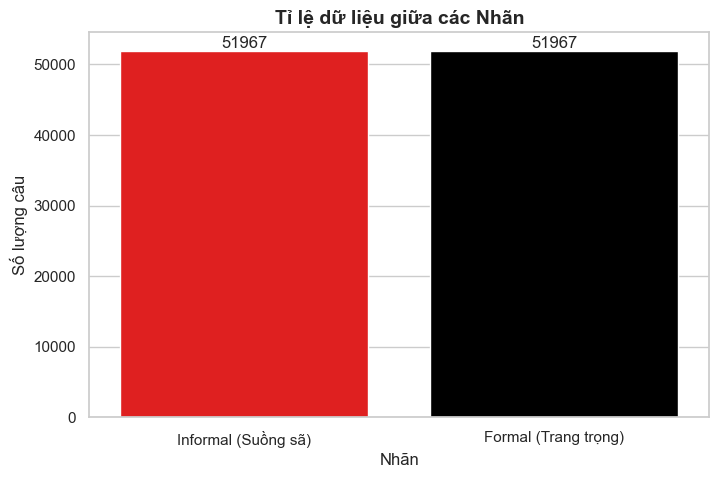

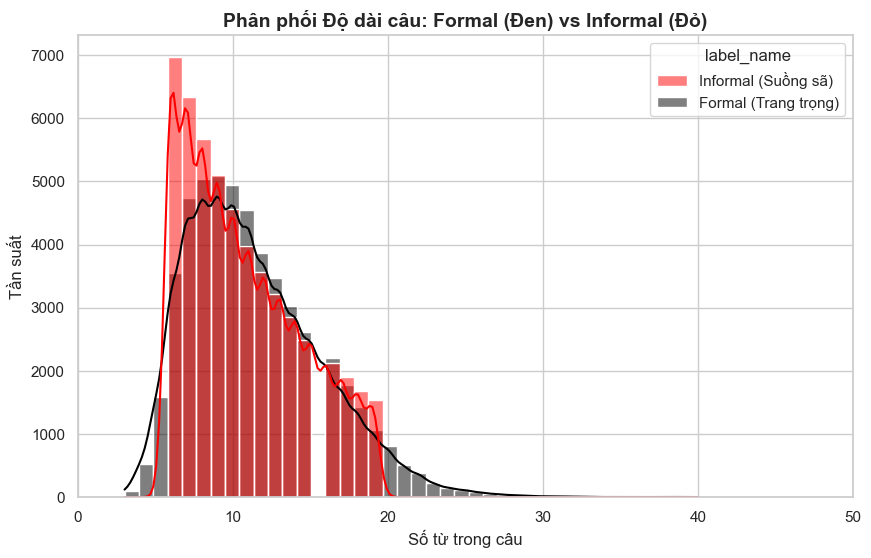

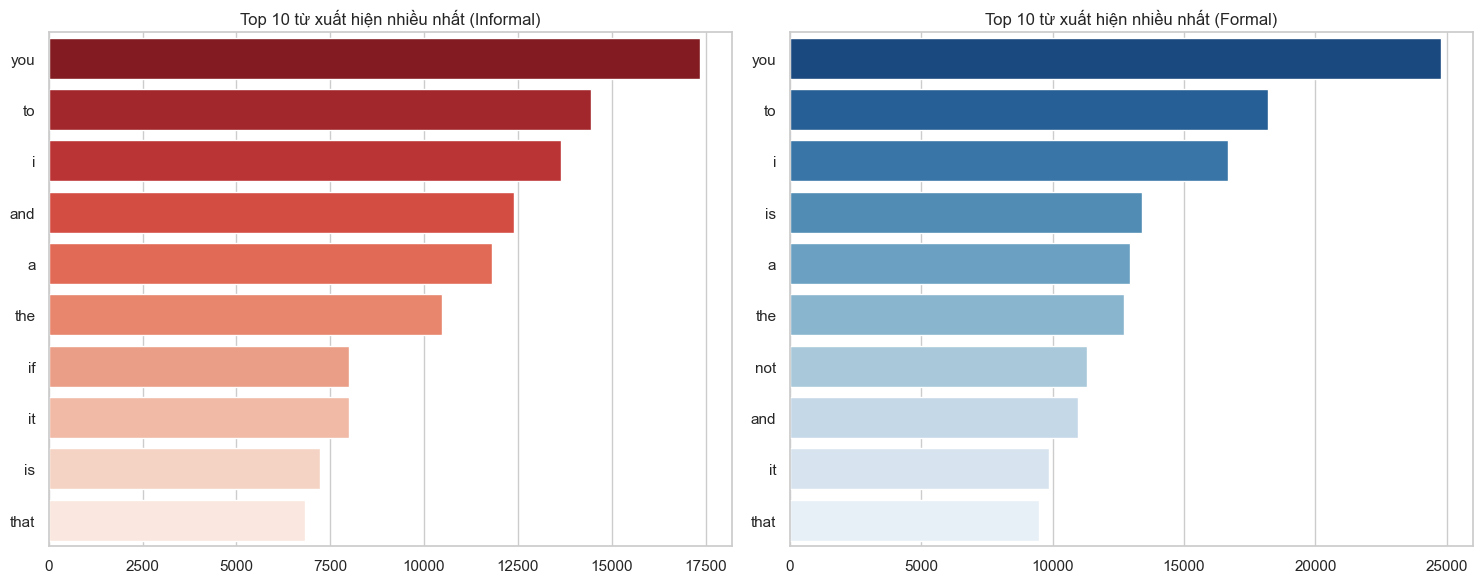

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


file_path = 'C:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_dataset_train_full.csv'

df = pd.read_csv(file_path)

# Thêm cột bổ trợ
df['label_name'] = df['label'].map({0: 'Informal (Suồng sã)', 1: 'Formal (Trang trọng)'})
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Thiết lập màu sắc tùy chỉnh: Đỏ cho Informal (0), Đen cho Formal (1)
custom_palette = ['red', 'black']


print(f"Tổng số dòng: {df.shape[0]}")
print(f"Có dòng nào bị thiếu dữ liệu không? \n{df.isnull().sum()}")

# Thiết lập phong cách biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")


# KHÍA CẠNH 1: ĐỘ CÂN BẰNG NHÃN (CLASS BALANCE)

plt.figure(figsize=(8, 5))
# Ánh xạ nhãn 0, 1 thành chữ cho dễ nhìn
df['label_name'] = df['label'].map({0: 'Informal (Suồng sã)', 1: 'Formal (Trang trọng)'})

ax = sns.countplot(x='label_name', hue='label_name', data=df, palette=custom_palette, legend=False)
plt.title('Tỉ lệ dữ liệu giữa các Nhãn', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng câu')

# Thêm con số trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

# ==========================================
# 2. BIỂU ĐỒ PHÂN PHỐI ĐỘ DÀI CÂU
# ==========================================
plt.figure(figsize=(10, 6))
# Sử dụng palette tùy chỉnh cho biểu đồ phân phối
sns.histplot(data=df, x='word_count', hue='label_name', bins=40, kde=True,
             palette=custom_palette, alpha=0.5)
plt.title('Phân phối Độ dài câu: Formal (Đen) vs Informal (Đỏ)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong câu')
plt.ylabel('Tần suất')
plt.xlim(0, 50)
plt.show()

# ==========================================
# KHÍA CẠNH 3: PHÂN TÍCH TỪ VỰNG (TOP WORDS)
# ==========================================
# Chú ý: Bước này làm thô để xem nhanh. Lát nữa dọn dẹp text xong (xóa Stopwords) thì biểu đồ sẽ còn xịn hơn.
def get_top_words(text_series, top_n=10):
    all_words = ' '.join(text_series.astype(str).str.lower()).split()
    return Counter(all_words).most_common(top_n)

informal_words = get_top_words(df[df['label'] == 0]['text'])
formal_words = get_top_words(df[df['label'] == 1]['text'])

# Tách từ và số lượng để vẽ
inf_words, inf_counts = zip(*informal_words)
form_words, form_counts = zip(*formal_words)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=list(inf_counts), y=list(inf_words), hue=list(inf_words), ax=axes[0], palette='Reds_r', legend=False)
axes[0].set_title('Top 10 từ xuất hiện nhiều nhất (Informal)', fontsize=12)

sns.barplot(x=list(form_counts), y=list(form_words), hue=list(form_words), ax=axes[1], palette='Blues_r', legend=False)
axes[1].set_title('Top 10 từ xuất hiện nhiều nhất (Formal)', fontsize=12)

plt.tight_layout()
plt.show()

#### Kiểm tra ngoại lệ (Outliers) - Đã comment out

In [5]:
import pandas as pd
import numpy as np

# Giả sử 'df' là bảng dữ liệu của bạn, có cột 'word_count' đã tính ở bước trước
print("--- TÌM KIẾM NGOẠI LỆ (OUTLIERS) TRONG VĂN BẢN ---")

# 1. Tìm Ngoại lệ Ngắn (Câu quá ngắn không đủ ngữ cảnh)
# Thường những câu dưới 3 từ sẽ không giúp ích nhiều cho mô hình
short_outliers = df[df['word_count'] < 3]
print(f"\n1. Số lượng câu quá ngắn (< 3 từ): {len(short_outliers)} câu")
if len(short_outliers) > 0:
    print("Ví dụ vài câu siêu ngắn:")
    display(short_outliers[['text', 'label']].head(3))

# 2. Tìm Ngoại lệ Dài (Sử dụng thống kê: Lớn hơn Phân vị thứ 99)
# Không dùng mức trung bình, ta tìm mốc độ dài bao trùm 99% dữ liệu
percentile_99 = np.percentile(df['word_count'], 99)
long_outliers = df[df['word_count'] > percentile_99]

print(f"\n2. Mốc 99% độ dài câu là: {int(percentile_99)} từ.")
print(f"Số lượng câu quá dài (>{int(percentile_99)} từ): {len(long_outliers)} câu")
if len(long_outliers) > 0:
    print("Ví dụ một câu siêu dài:")
    print(long_outliers.iloc[0]['text'])

# 3. Cách xử lý (Lọc bỏ ngoại lệ)
# Lấy những câu có độ dài từ 3 từ đến mức phân vị 99
df_no_outliers = df[(df['word_count'] >= 3) & (df['word_count'] <= percentile_99)].copy()

print(f"\n--- TỔNG KẾT ---")
print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi loại bỏ ngoại lệ: {len(df_no_outliers)}")

--- TÌM KIẾM NGOẠI LỆ (OUTLIERS) TRONG VĂN BẢN ---

1. Số lượng câu quá ngắn (< 3 từ): 0 câu

2. Mốc 99% độ dài câu là: 22 từ.
Số lượng câu quá dài (>22 từ): 713 câu
Ví dụ một câu siêu dài:
If you plan on creating children, they require a lot of care. Such as, prenatal care, baby furniture, for example a stroller, clothes, food, and more.

--- TỔNG KẾT ---
Số dòng ban đầu: 103934
Số dòng sau khi loại bỏ ngoại lệ: 103221


#### Chuẩn bị dữ liệu cho Transformer (gyafc_transformer_ready.csv)

In [ ]:
import pandas as pd
import numpy as np


print("1. Đang đọc dữ liệu gốc...")
file_path = 'C:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_dataset_train_full.csv'
df_transformer = pd.read_csv(file_path)

# Tính toán số từ trong mỗi câu
df_transformer['word_count'] = df_transformer['text'].apply(lambda x: len(str(x).split()))

print("2. Đang lọc ngoại lệ (Chỉ giữ câu từ 3 từ đến mức phân vị 99)...")
percentile_99 = np.percentile(df_transformer['word_count'], 99)
df_filtered = df_transformer[(df_transformer['word_count'] >= 3) & (df_transformer['word_count'] <= percentile_99)].copy()

print("3. Đang dọn dẹp khoảng trắng thừa (GIỮ NGUYÊN dấu câu và chữ hoa/thường)...")
# Chỉ xóa các khoảng trắng bị dư thừa ở hai đầu câu
df_filtered['text'] = df_filtered['text'].astype(str).str.strip()

# Loại bỏ những câu nếu sau khi strip() chỉ còn là chuỗi rỗng
df_final_transformer = df_filtered[df_filtered['text'] != '']

# Chỉ giữ lại 2 cột quan trọng nhất để đưa vào mô hình AI
df_final_transformer = df_final_transformer[['text', 'label']]


save_path = 'C:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_transformer_ready.csv'
df_final_transformer.to_csv(save_path, index=False)


print(f"- Đường dẫn trên Drive: {save_path}")
print(f"- Số lượng câu dữ liệu: {len(df_final_transformer)} dòng.")




1. Đang đọc dữ liệu gốc...
2. Đang lọc ngoại lệ (Chỉ giữ câu từ 3 từ đến mức phân vị 99)...
3. Đang dọn dẹp khoảng trắng thừa (GIỮ NGUYÊN dấu câu và chữ hoa/thường)...
4. Đang lưu file xuống Google Drive...

✅ HOÀN THÀNH!
- Đường dẫn trên Drive: C:/Users/Admin/Documents/testvscode/formalityClassificationProject/data/gyafc_transformer_ready.csv
- Số lượng câu dữ liệu: 103221 dòng.

5. Đang kích hoạt tải file về máy tính cá nhân của bạn...
